In [ ]:
from pathlib import Path

import openeo
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd

print("openEO version:", openeo.client_version())

In [ ]:
project_root = Path.cwd()

# Utile nel caso in cui VS Code esegua il notebook
# usando notebooks/ come cartella corrente.
if project_root.name == "notebooks":
    project_root = project_root.parent

raw_data_dir = project_root / "data" / "raw"
raw_data_dir.mkdir(parents=True, exist_ok=True)

output_path = raw_data_dir / "sentinel5p_ch4_test_june_2024.nc"

print("Project root:", project_root)
print("Output file:", output_path)

In [ ]:
connection = openeo.connect(
    url="openeo.dataspace.copernicus.eu"
)

connection.authenticate_oidc()

In [ ]:
collection = connection.describe_collection("SENTINEL_5P_L2")
bands = collection["cube:dimensions"]["bands"]["values"]
assert "CH4" in bands
print("CH4 band available.")

In [ ]:
test_extent = {
    "west": 8.5,
    "south": 44.8,
    "east": 10.5,
    "north": 46.0,
    "crs": "EPSG:4326",
}

test_period = ["2024-06-01", "2024-07-01"]

ch4_cube = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent=test_extent,
    temporal_extent=test_period,
    bands=["CH4"],
)

ch4_cube

In [ ]:
ch4_cube.print_json()

In [ ]:
if not output_path.exists():
    ch4_cube.download(
        outputfile=output_path,
        format="NetCDF",
    )
    print("Download completed.")
else:
    print("File already exists:", output_path)

In [ ]:
ds = xr.open_dataset(output_path)

ds

In [ ]:
print("Dimensions:")
print(ds.sizes)

print("\nCoordinates:")
print(list(ds.coords))

print("\nData variables:")
print(list(ds.data_vars))

In [ ]:
assert "CH4" in ds.data_vars, (
    f"CH4 not found. Available variables: {list(ds.data_vars)}"
)

ch4 = ds["CH4"]

ch4

In [ ]:
print("CH4 dimensions:", ch4.dims)
print("CH4 shape:", ch4.shape)
print("CH4 attributes:", ch4.attrs)

In [ ]:
print("Valid observations:", ch4.count().values)
print("Minimum:", ch4.min(skipna=True).values)
print("Maximum:", ch4.max(skipna=True).values)
print("Mean:", ch4.mean(skipna=True).values)

In [ ]:
time_dim = next(
    (dim for dim in ["t", "time"] if dim in ch4.dims),
    None,
)

print("Time dimension:", time_dim)

In [ ]:
if time_dim is not None:
    first_time = pd.to_datetime(ch4[time_dim].values[0])

    first_observation = ch4.isel({time_dim: 0})

    first_observation.plot(
        figsize=(9, 6),
        robust=True,
    )

    plt.title(f"Sentinel-5P CH₄ — {first_time:%Y-%m-%d}")
    plt.show()
else:
    print("No temporal dimension found.")

In [ ]:
if time_dim is not None:
    spatial_dims = [
        dim for dim in ch4.dims
        if dim != time_dim
    ]

    regional_mean = ch4.mean(
        dim=spatial_dims,
        skipna=True,
    )

    regional_mean.plot(
        marker="o",
        figsize=(10, 5),
    )

    plt.title("Mean satellite-observed CH₄ over the test area")
    plt.ylabel("CH₄")
    plt.grid()
    plt.show()

In [11]:
pilot_extent = {
    "west": 7.5,
    "south": 44.3,
    "east": 13.0,
    "north": 46.7,
    "crs": "EPSG:4326",
}

pilot_period = [
    "2024-01-01",
    "2025-01-01",
]

pilot_cube = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent=pilot_extent,
    temporal_extent=pilot_period,
    bands=["CH4"],
)

pilot_weekly_cube = pilot_cube.aggregate_temporal_period(
    period="week",
    reducer="mean",
)

In [ ]:
#Open pilot dataset:

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

pilot_output_path = (
    project_root
    / "data"
    / "interim"
    / "sentinel5p_ch4_po_valley_weekly_2024.nc"
)

ds_pilot = xr.open_dataset(pilot_output_path)
ch4_pilot = ds_pilot["CH4"]

ch4_pilot

In [ ]:
times = pd.DatetimeIndex(ch4_pilot["t"].values)

print("Number of timestamps:", len(times))
print("First timestamp:", times.min())
print("Last timestamp:", times.max())
print(times)

In [ ]:
time_differences = pd.Series(times).diff()

print(time_differences.value_counts())

In [18]:
spatial_dims = ["y", "x"]

valid_values_per_week = ch4_pilot.count(dim=spatial_dims)

total_spatial_cells = (
    ch4_pilot.sizes["y"]
    * ch4_pilot.sizes["x"]
)

coverage_per_week = valid_values_per_week / total_spatial_cells

In [ ]:
weekly_coverage_df = pd.DataFrame({
    "week": times,
    "valid_cells": valid_values_per_week.values,
    "coverage": coverage_per_week.values,
})

weekly_coverage_df["missing_proportion"] = (
    1 - weekly_coverage_df["coverage"]
)

weekly_coverage_df.head()

In [ ]:
weekly_coverage_df.sort_values("coverage").head(10)

In [ ]:
weekly_coverage_df.sort_values(
    "coverage",
    ascending=False,
).head(10)

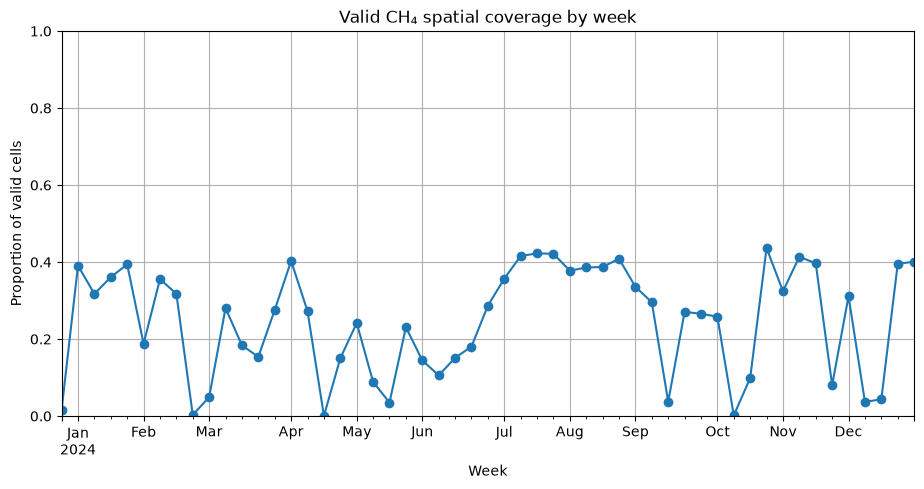

In [20]:
weekly_coverage_df.plot(
    x="week",
    y="coverage",
    figsize=(11, 5),
    marker="o",
    legend=False,
)

plt.title("Valid CH₄ spatial coverage by week")
plt.xlabel("Week")
plt.ylabel("Proportion of valid cells")
plt.ylim(0, 1)
plt.grid()
plt.show()

In [ ]:
weekly_coverage_df["coverage"].describe()

In [ ]:
very_low_coverage_weeks = weekly_coverage_df[weekly_coverage_df["coverage"] < 0.05]

very_low_coverage_weeks

In [ ]:
empty_weeks = weekly_coverage_df[weekly_coverage_df["valid_cells"] == 0]

empty_weeks

In [ ]:
valid_weeks_per_cell = ch4_pilot.count(dim="t")

cell_coverage = (
    valid_weeks_per_cell
    / ch4_pilot.sizes["t"]
)

cell_coverage

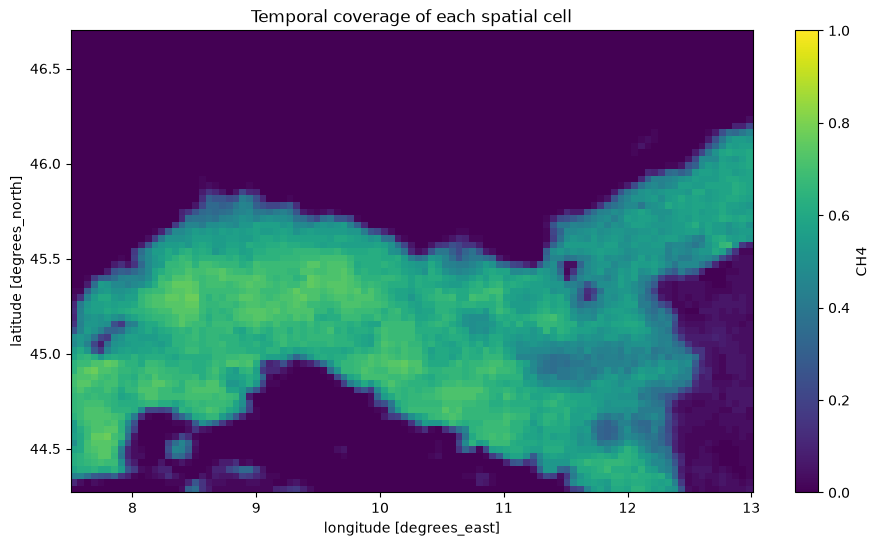

In [24]:
cell_coverage.plot(
    figsize=(11, 6),
    vmin=0,
    vmax=1,
)

plt.title("Temporal coverage of each spatial cell")
plt.show()

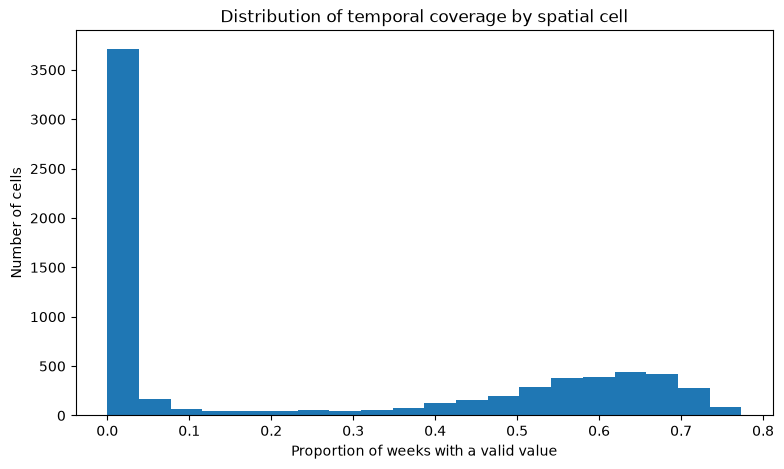

In [25]:
cell_coverage.plot.hist(
    bins=20,
    figsize=(9, 5),
)

plt.title("Distribution of temporal coverage by spatial cell")
plt.xlabel("Proportion of weeks with a valid value")
plt.ylabel("Number of cells")
plt.show()

In [40]:
coverage_thresholds = [0.0, 0.10, 0.25, 0.50, 0.75]

for threshold in coverage_thresholds:
    number_of_cells = int(
        (cell_coverage > threshold).sum().values
    )

    print(
        f"Cells with coverage > {threshold:.0%}: "
        f"{number_of_cells}"
    )

Cells with coverage > 0%: 3734
Cells with coverage > 10%: 3162
Cells with coverage > 25%: 2973
Cells with coverage > 50%: 2282
Cells with coverage > 75%: 21


In [ ]:
x_coordinates = ch4_pilot["x"]
y_coordinates = ch4_pilot["y"]

print(x_coordinates)
print(y_coordinates)

In [ ]:
print("x range:")
print(float(x_coordinates.min()), float(x_coordinates.max()))

print("\ny range:")
print(float(y_coordinates.min()), float(y_coordinates.max()))

print("\nx attributes:")
print(x_coordinates.attrs)

print("\ny attributes:")
print(y_coordinates.attrs)

In [ ]:
x_steps = np.diff(x_coordinates.values)
y_steps = np.diff(y_coordinates.values)

print("Unique x steps:")
print(np.unique(np.round(x_steps, 10)))

print("\nUnique y steps:")
print(np.unique(np.round(y_steps, 10)))

In [ ]:
print("x resolution:", abs(x_steps[0]))
print("y resolution:", abs(y_steps[0]))

In [ ]:
print("Dataset attributes:")
print(ds_pilot.attrs)

In [ ]:
possible_crs_variables = [
    variable
    for variable in ds_pilot.variables
    if (
        "crs" in variable.lower()
        or "spatial_ref" in variable.lower()
    )
]

print("Possible CRS variables:", possible_crs_variables)

In [ ]:
for variable in possible_crs_variables:
    print(f"\n{variable}:")
    print(ds_pilot[variable].attrs)

Cells retained: 2973
Cells excluded: 4097


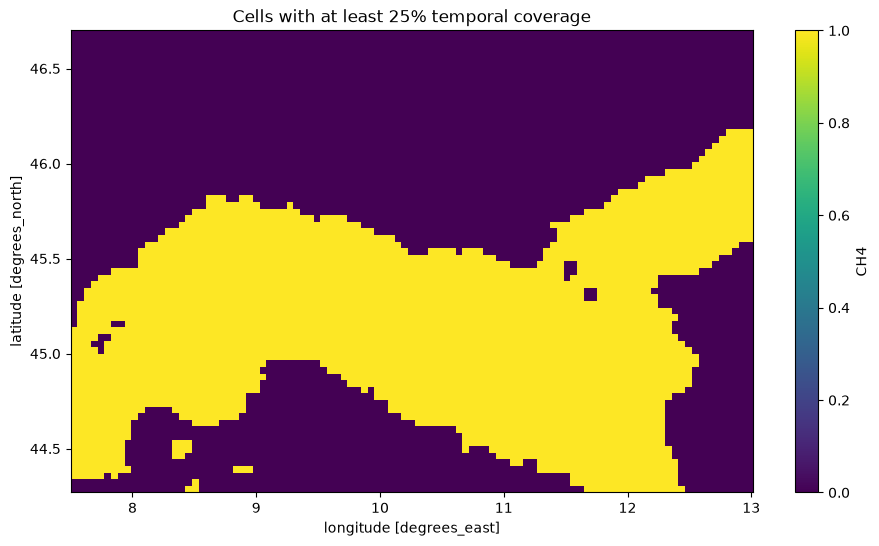

In [26]:
minimum_cell_coverage = 0.25

sufficient_coverage_mask = (
    cell_coverage >= minimum_cell_coverage
)

print(
    "Cells retained:",
    int(sufficient_coverage_mask.sum().values),
)

print(
    "Cells excluded:",
    int((~sufficient_coverage_mask).sum().values),
)

sufficient_coverage_mask.plot(
    figsize=(11, 6),
)

plt.title(
    "Cells with at least 25% temporal coverage"
)
plt.show()

In [29]:
regions_dir = project_root / "data" / "regions"

roi_path = (
    regions_dir
    / "po_valley_provisional_envelope_roi.geojson"
)

po_valley_roi = gpd.read_file(roi_path)

In [ ]:
print("CRS:", po_valley_roi.crs)
print("Geometry type:", po_valley_roi.geometry.geom_type.tolist())
print("Bounds:", po_valley_roi.total_bounds)

po_valley_roi

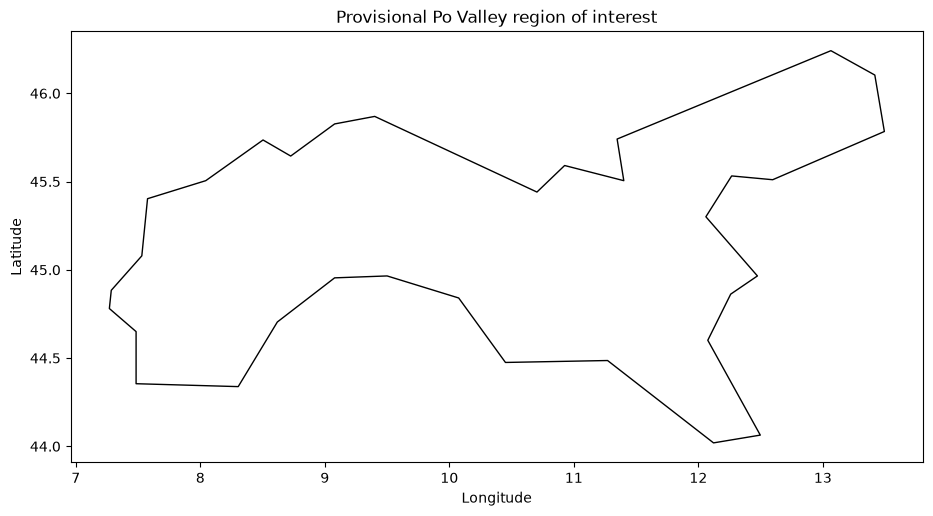

In [31]:
po_valley_roi.plot(
    figsize=(11, 6),
    facecolor="none",
    edgecolor="black",
)

plt.title("Provisional Po Valley region of interest")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

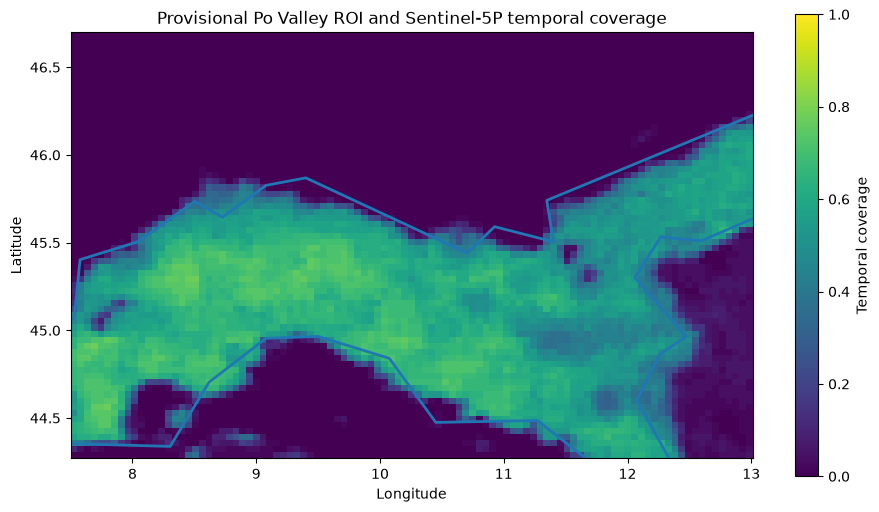

In [32]:
fig, ax = plt.subplots(figsize=(11, 6))

cell_coverage.rename("Temporal coverage").plot(
    ax=ax,
    vmin=0,
    vmax=1,
)

po_valley_roi.boundary.plot(
    ax=ax,
    linewidth=2,
)

ax.set_title(
    "Provisional Po Valley ROI and Sentinel-5P temporal coverage"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [33]:
import regionmask

roi_mask = regionmask.mask_geopandas(
    po_valley_roi,
    ch4_pilot["x"],
    ch4_pilot["y"],
)

inside_roi = roi_mask.notnull()

number_of_roi_cells = int(inside_roi.sum().values)

mean_coverage_inside = float(
    cell_coverage.where(inside_roi).mean(skipna=True).values
)

median_coverage_inside = float(
    cell_coverage.where(inside_roi).median(skipna=True).values
)

print("Cells inside ROI:", number_of_roi_cells)
print("Mean temporal coverage:", mean_coverage_inside)
print("Median temporal coverage:", median_coverage_inside)

Cells inside ROI: 2974
Mean temporal coverage: 0.5391823476418266
Median temporal coverage: 0.5849056603773585


In [34]:
ch4_roi = ch4_pilot.where(inside_roi)

In [35]:
roi_cell_coverage = (
    ch4_roi.count(dim="t")
    / ch4_roi.sizes["t"]
).rename("temporal_coverage")

minimum_coverage = 0.25

final_spatial_mask = (
    inside_roi
    & (roi_cell_coverage >= minimum_coverage)
).rename("candidate_cells")

In [36]:
ch4_candidate = ch4_pilot.where(final_spatial_mask)

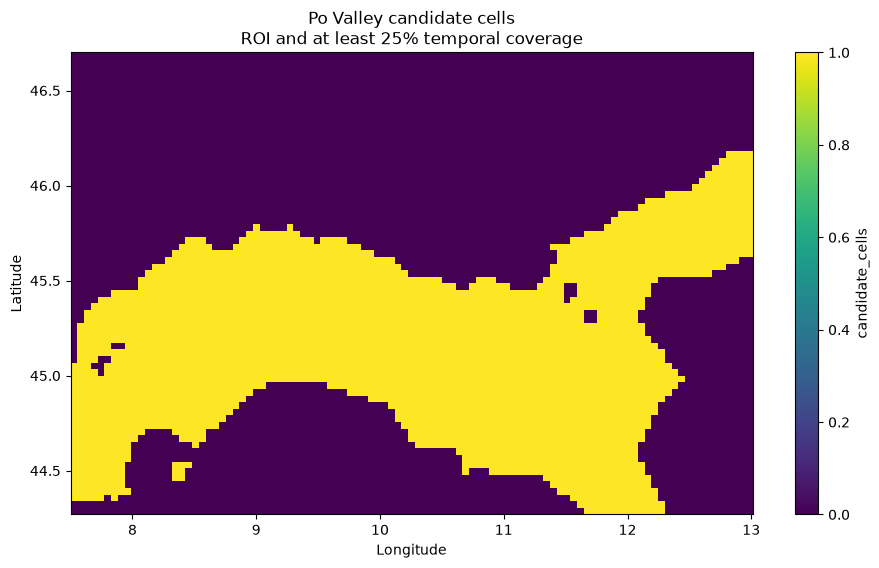

In [37]:
final_spatial_mask.plot(
    figsize=(11, 6),
)

plt.title(
    "Po Valley candidate cells\n"
    "ROI and at least 25% temporal coverage"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

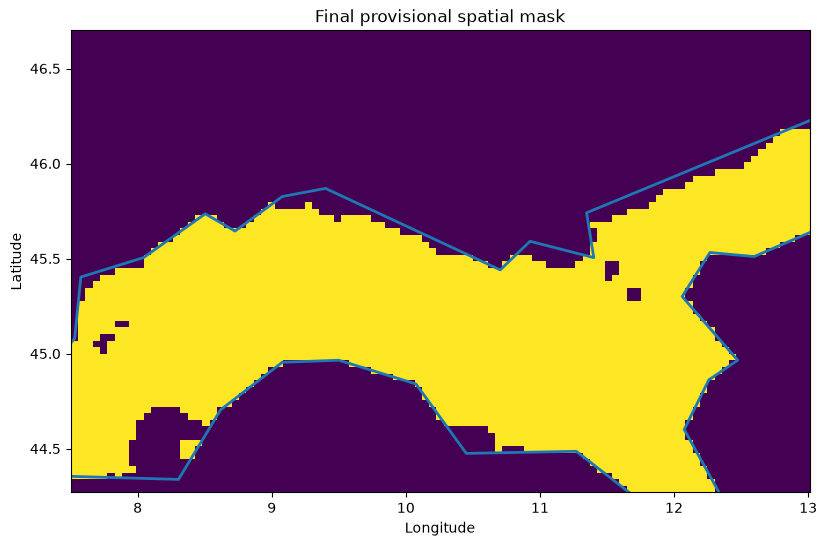

In [38]:
fig, ax = plt.subplots(figsize=(11, 6))

final_spatial_mask.plot(
    ax=ax,
    add_colorbar=False,
)

po_valley_roi.boundary.plot(
    ax=ax,
    linewidth=2,
)

ax.set_title(
    "Final provisional spatial mask"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [39]:
current_week_valid = ch4_candidate.notnull().isel(
    t=slice(0, -1)
)

next_week_valid = ch4_candidate.notnull().isel(
    t=slice(1, None)
)

# Rimuoviamo le coordinate temporali differenti per confrontare
# le due sequenze posizione per posizione.
current_week_valid = current_week_valid.assign_coords(
    t=np.arange(current_week_valid.sizes["t"])
)

next_week_valid = next_week_valid.assign_coords(
    t=np.arange(next_week_valid.sizes["t"])
)

valid_consecutive_pairs = (
    current_week_valid
    & next_week_valid
)

pairs_per_cell = valid_consecutive_pairs.sum(
    dim="t"
)

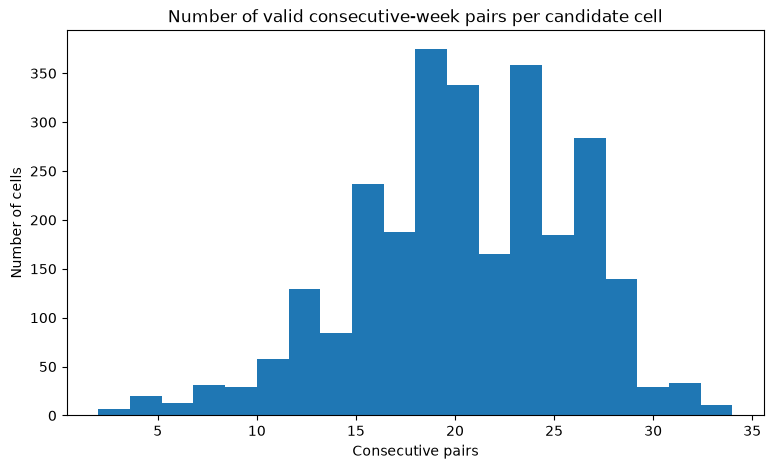

In [40]:
pairs_per_cell.where(
    final_spatial_mask
).plot.hist(
    bins=20,
    figsize=(9, 5),
)

plt.title(
    "Number of valid consecutive-week pairs per candidate cell"
)
plt.xlabel("Consecutive pairs")
plt.ylabel("Number of cells")
plt.show()

In [41]:
total_valid_pairs = int(valid_consecutive_pairs.sum().values)

print("Total valid consecutive-week pairs:", total_valid_pairs)

Total valid consecutive-week pairs: 55278
